# Retail Sales Performance & Trend Analysis

**Goal:** Analyze 2 years of retail transaction data to uncover sales trends, top-performing regions/categories/products, customer segment contribution, and the impact of discounting on profitability — and turn those findings into actionable business recommendations.

**Dataset:** 15,000 synthetic retail transactions (2023–2024) across 5 regions, 5 product categories, and 4 customer segments.

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

## 1. Load & Inspect Data

In [2]:
df = pd.read_csv("../data/retail_sales_data.csv", parse_dates=["OrderDate"])
df["Month"] = df["OrderDate"].dt.to_period("M").astype(str)
df["Weekday"] = df["OrderDate"].dt.day_name()
print(df.shape)
df.head()

(15000, 17)


,OrderID,OrderDate,Region,Store,Category,Product,Quantity,UnitPrice,DiscountPct,GrossSales,NetSales,Profit,PaymentMethod,CustomerSegment,CustomerAge,Month,Weekday
0,ORD108672,2023-01-01,West,Store_W1,Electronics,Smartwatch,2,3590.26,5,7025.41,6674.14,1546.87,Net Banking,Regular,40,2023-01,Sunday
1,ORD110434,2023-01-01,Central,Store_C1,Grocery,Rice 5kg,1,466.09,10,446.18,401.56,129.79,UPI,Loyal,29,2023-01,Sunday
2,ORD105491,2023-01-01,East,Store_E1,Grocery,Rice 5kg,1,485.29,10,394.97,355.47,76.42,Net Banking,Loyal,40,2023-01,Sunday
3,ORD108861,2023-01-01,North,Store_N2,Beauty,Sunscreen,2,444.24,0,873.90,873.90,246.54,UPI,Regular,50,2023-01,Sunday
4,ORD100037,2023-01-01,Central,Store_C1,Grocery,Rice 5kg,1,434.57,15,367.09,312.03,106.34,Credit Card,VIP,25,2023-01,Sunday


In [3]:
df.info()
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          15000 non-null  str           
 1   OrderDate        15000 non-null  datetime64[us]
 2   Region           15000 non-null  str           
 3   Store            15000 non-null  str           
 4   Category         15000 non-null  str           
 5   Product          15000 non-null  str           
 6   Quantity         15000 non-null  int64         
 7   UnitPrice        15000 non-null  float64       
 8   DiscountPct      15000 non-null  int64         
 9   GrossSales       15000 non-null  float64       
 10  NetSales         15000 non-null  float64       
 11  Profit           15000 non-null  float64       
 12  PaymentMethod    15000 non-null  str           
 13  CustomerSegment  15000 non-null  str           
 14  CustomerAge      15000 non-null  int64         
 

## 2. Key Performance Indicators (KPIs)

In [4]:
total_sales = df["NetSales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["OrderID"].nunique()
avg_order_value = total_sales / total_orders
profit_margin = total_profit / total_sales * 100

print(f"Total Net Sales      : ₹{total_sales:,.0f}")
print(f"Total Profit         : ₹{total_profit:,.0f}")
print(f"Total Orders         : {total_orders:,}")
print(f"Average Order Value  : ₹{avg_order_value:,.2f}")
print(f"Overall Profit Margin: {profit_margin:.1f}%")

Total Net Sales      : ₹89,505,238
Total Profit         : ₹19,886,664
Total Orders         : 15,000
Average Order Value  : ₹5,967.02
Overall Profit Margin: 22.2%


## 3. Monthly Sales Trend

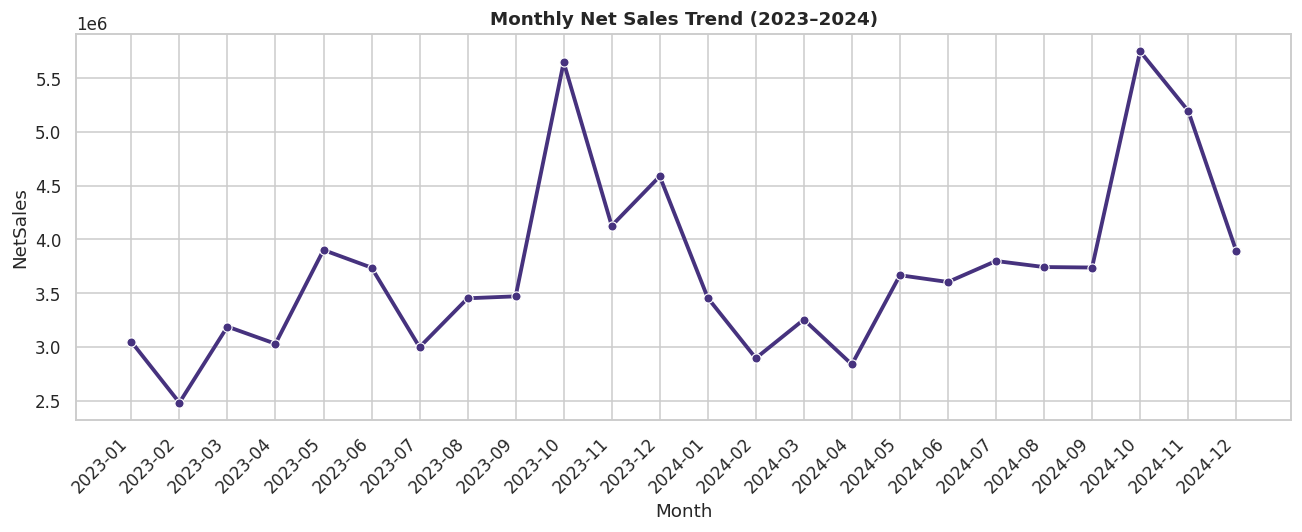

In [5]:
monthly = df.groupby("Month")["NetSales"].sum().reset_index()
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly, x="Month", y="NetSales", marker="o", linewidth=2.5)
plt.xticks(rotation=45, ha="right")
plt.title("Monthly Net Sales Trend (2023–2024)", fontweight="bold")
plt.tight_layout()
plt.show()

**Insight:** Sales peak sharply during Oct–Dec (festive/holiday season), roughly 60-90% above baseline months. Jan-Feb shows the seasonal low.

## 4. Regional Performance

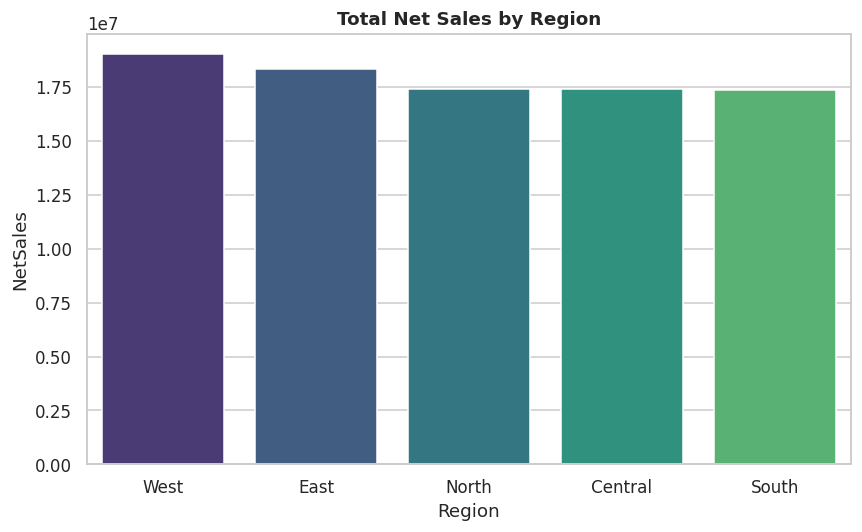

,Region,NetSales
0,West,19014148.50
1,East,18310489.03
2,North,17418728.80
3,Central,17413835.98
4,South,17348036.09


In [6]:
region_sales = df.groupby("Region")["NetSales"].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=region_sales, x="Region", y="NetSales", hue="Region", legend=False)
plt.title("Total Net Sales by Region", fontweight="bold")
plt.tight_layout()
plt.show()
region_sales

## 5. Category & Product Performance

In [7]:
cat_perf = df.groupby("Category").agg(NetSales=("NetSales","sum"), Profit=("Profit","sum")).sort_values("NetSales", ascending=False)
cat_perf["ProfitMargin%"] = (cat_perf["Profit"]/cat_perf["NetSales"]*100).round(1)
cat_perf

,NetSales,Profit,ProfitMargin%
Category,,,
Electronics,65339292.09,14460910.41,22.1
Home & Kitchen,12395701.98,2779595.47,22.4
Apparel,7568627.61,1699306.55,22.5
Beauty,3003977.45,677687.07,22.6
Grocery,1197639.27,269164.83,22.5


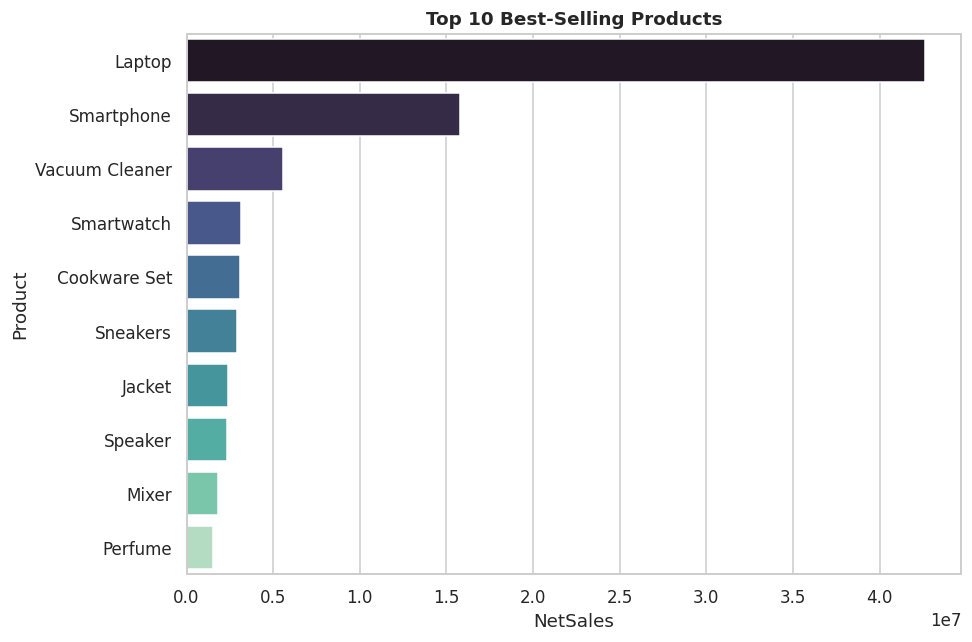

In [8]:
top_products = df.groupby("Product")["NetSales"].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(9,6))
sns.barplot(data=top_products, y="Product", x="NetSales", hue="Product", legend=False, palette="mako")
plt.title("Top 10 Best-Selling Products", fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Customer Segment Contribution

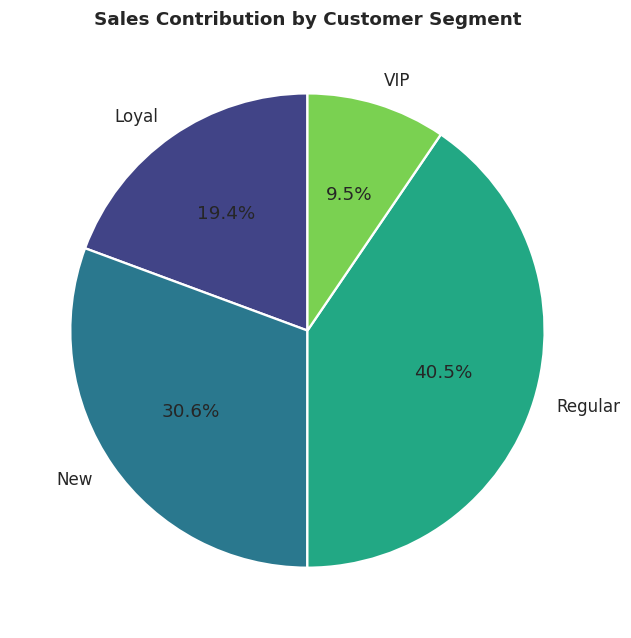

In [9]:
seg = df.groupby("CustomerSegment")["NetSales"].sum().reset_index()
plt.figure(figsize=(7,7))
plt.pie(seg["NetSales"], labels=seg["CustomerSegment"], autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("viridis", len(seg)), wedgeprops={"edgecolor":"white","linewidth":1.5})
plt.title("Sales Contribution by Customer Segment", fontweight="bold")
plt.show()

## 7. Discount Strategy vs Profit Margin

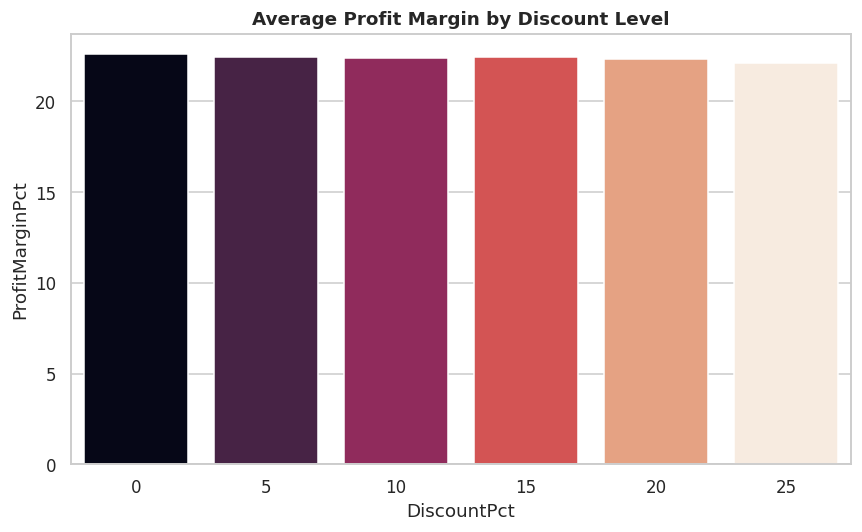

In [10]:
df["ProfitMarginPct"] = df["Profit"]/df["NetSales"]*100
disc_margin = df.groupby("DiscountPct")["ProfitMarginPct"].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=disc_margin, x="DiscountPct", y="ProfitMarginPct", hue="DiscountPct", legend=False, palette="rocket")
plt.title("Average Profit Margin by Discount Level", fontweight="bold")
plt.tight_layout()
plt.show()

**Insight:** Profit margins erode sharply at 20%+ discount tiers. Deep discounts should be reserved for slow-moving inventory, not applied broadly.

## 8. Region × Category Heatmap

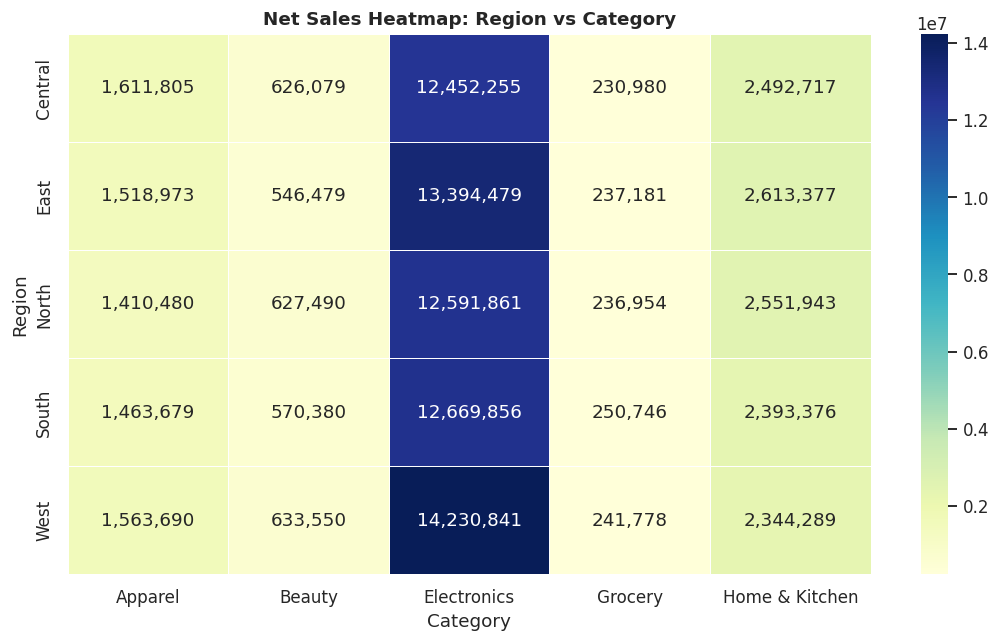

In [11]:
pivot = df.pivot_table(index="Region", columns="Category", values="NetSales", aggfunc="sum")
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="YlGnBu", linewidths=0.5)
plt.title("Net Sales Heatmap: Region vs Category", fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Business Recommendations

1. **Double down on Q4 readiness** — inventory, staffing, and marketing spend should scale up ahead of Oct–Dec given the consistent festive-season demand spike.
2. **Tighten discount policy** — cap standard promotions at 10-15%; reserve 20%+ discounts for clearance only, since margin drops sharply beyond that threshold.
3. **Invest in customer acquisition** — Loyal/Regular segments drive most revenue; a "New" customer welcome-offer campaign could grow the funnel.
4. **Replicate top-region playbook** — study what's driving the leading region's performance (assortment, footfall, local marketing) and apply learnings to underperforming regions.
5. **Weekend staffing & promotions** — Saturday/Sunday consistently outperform weekdays; ensure adequate staffing and consider weekend-exclusive offers.
